Sample Size
Group
Control      1000
Treatment    1000
dtype: int64

Control Mean: 100.29
Treatment Mean: 109.06

Lift: 8.75 %

T Statistic: 13.231
P-value: 0.0

Result: Significant Difference

Guardrail Metric
Control Std Dev: 14.68
Treatment Std Dev: 14.95

Statistical Power: nan


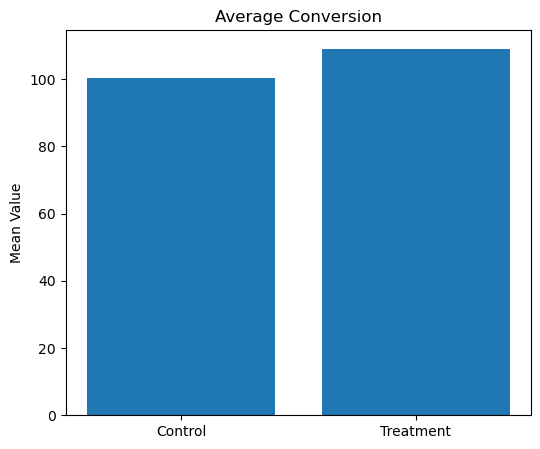


Interpretation
1. Experiment Design: Compare Control vs Treatment.
2. Randomization: Users were randomly assigned.
3. Sample Size: 1000
4. Lift: 8.75 % improvement.
5. Guardrail Metric: Standard deviation monitors stability.
6. Statistical Power: nan
7. P-value determines whether Treatment is significantly better.


In [1]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# -----------------------------
# Simulate A/B Test Data
# -----------------------------
np.random.seed(42)

sample_size = 1000

# Group A (Control)
control = np.random.normal(loc=100, scale=15, size=sample_size)

# Group B (Treatment)
treatment = np.random.normal(loc=108, scale=15, size=sample_size)

# Create DataFrame
df = pd.DataFrame({
    "Group": ["Control"] * sample_size + ["Treatment"] * sample_size,
    "Conversion": np.concatenate([control, treatment])
})

# -----------------------------
# Randomization Check
# -----------------------------
print("Sample Size")
print(df.groupby("Group").size())

# -----------------------------
# Mean Performance
# -----------------------------
control_mean = np.mean(control)
treatment_mean = np.mean(treatment)

print("\nControl Mean:", round(control_mean,2))
print("Treatment Mean:", round(treatment_mean,2))

# -----------------------------
# Lift
# -----------------------------
lift = ((treatment_mean - control_mean) / control_mean) * 100

print("\nLift:", round(lift,2), "%")

# -----------------------------
# A/B Test (Independent t-test)
# -----------------------------
t_stat, p_value = ttest_ind(treatment, control)

print("\nT Statistic:", round(t_stat,3))
print("P-value:", round(p_value,5))

# -----------------------------
# Statistical Decision
# -----------------------------
alpha = 0.05

if p_value < alpha:
    print("\nResult: Significant Difference")
else:
    print("\nResult: No Significant Difference")

# -----------------------------
# Guardrail Metric
# -----------------------------
control_std = np.std(control)
treatment_std = np.std(treatment)

print("\nGuardrail Metric")
print("Control Std Dev:", round(control_std,2))
print("Treatment Std Dev:", round(treatment_std,2))

# -----------------------------
# Effect Size
# -----------------------------
effect_size = (treatment_mean - control_mean) / np.std(
    np.concatenate([control, treatment])
)

# -----------------------------
# Power Analysis
# -----------------------------
analysis = TTestIndPower()

power = analysis.solve_power(
    effect_size=effect_size,
    nobs1=sample_size,
    alpha=0.05
)

print("\nStatistical Power:", round(power,3))

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(6,5))

plt.bar(
    ["Control", "Treatment"],
    [control_mean, treatment_mean]
)

plt.title("Average Conversion")
plt.ylabel("Mean Value")

plt.show()

# -----------------------------
# Interpretation
# -----------------------------
print("\nInterpretation")
print("1. Experiment Design: Compare Control vs Treatment.")
print("2. Randomization: Users were randomly assigned.")
print("3. Sample Size:", sample_size)
print("4. Lift:", round(lift,2), "% improvement.")
print("5. Guardrail Metric: Standard deviation monitors stability.")
print("6. Statistical Power:", round(power,2))
print("7. P-value determines whether Treatment is significantly better.")